Mounted at /content/drive
✅ Unzipped successfully to: /content/drive/MyDrive/mainfolder_extracted

🔍 Checking extracted folder contents...

📂 Folder: /content/drive/MyDrive/mainfolder_extracted

📂 Folder: /content/drive/MyDrive/mainfolder_extracted/mainfolder
  - sales_data.csv

📂 Folder: /content/drive/MyDrive/mainfolder_extracted/mainfolder/product_descriptions
  - description_CMWKCILOP27KF.txt
  - description_AISJDKFJW93NJ.txt
  - description_GGOENEBJ079499.txt
  - description_HJSKNWK429DJE.txt
  - description_DJKFIEI432FIE.txt
  - description_JFKL3940NFKLJ.txt
  - description_MWKDI3JFK39SL.txt
  - description_LKDFJ49LSDJKL.txt
  - description_OWEJL398FWJLK.txt
  - description_NEKFJOWE9FDIW.txt
  - description_XPLFJW2490XJN.txt

📂 Folder: /content/drive/MyDrive/mainfolder_extracted/mainfolder/product_details
  - details_CMWKCILOP27KF.json
  - details_DJKFIEI432FIE.json
  - details_HJSKNWK429DJE.json
  - details_AISJDKFJW93NJ.json
  - details_GGOENEBJ079499.json
  - details_JFKL3940N

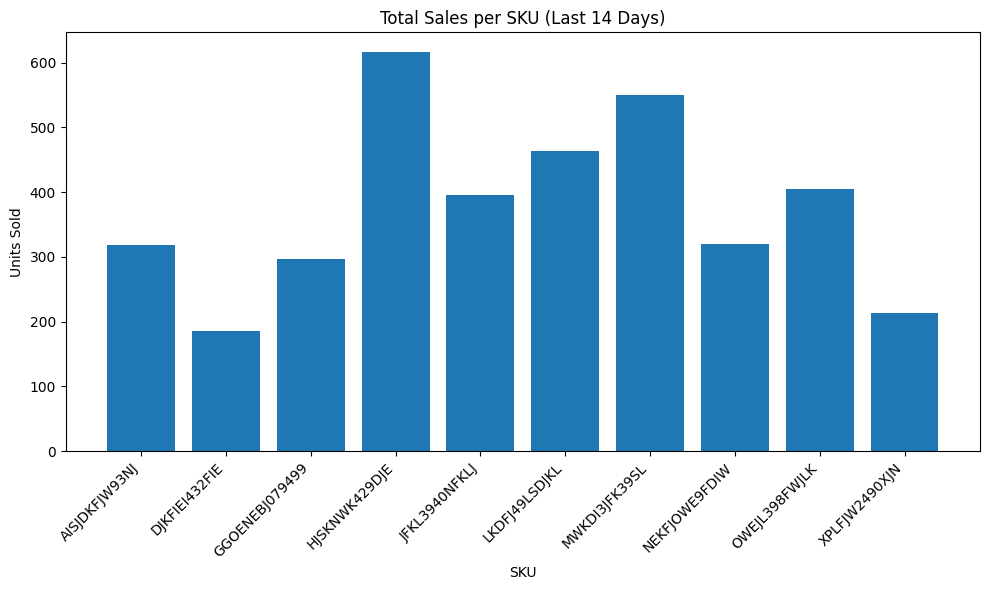

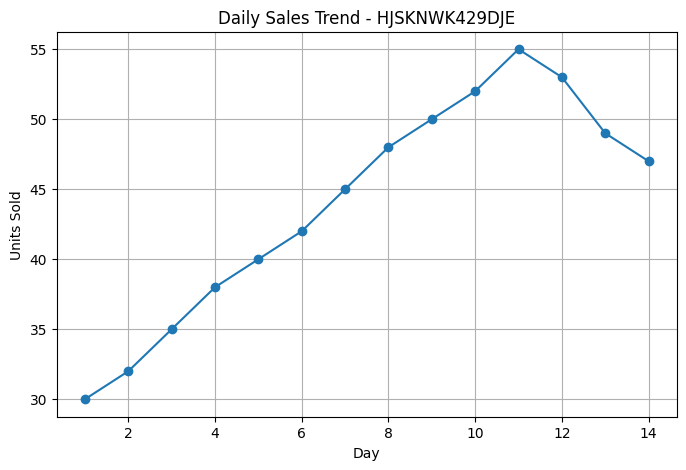


📋 MENU OPTIONS:
1. Add / Update a Product
2. Run Exploratory Data Analysis (EDA)
3. Save & Exit
4. Exit without Saving
Enter your choice (1–4): 3
💾 Data saved successfully!
✅ All changes saved. Exiting...


In [ ]:
# ---------------------- IMPORTS & ENVIRONMENT SETUP ----------------------

import os
import zipfile
import json
import csv
import re
import matplotlib.pyplot as plt

# ---------------------- DETECT COLAB OR LOCAL ----------------------

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ---------------------- PATHS AND UNZIP ----------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    zip_path = "/content/drive/MyDrive/mainfolder.zip"
    extract_path = "/content/drive/MyDrive/mainfolder_extracted"

    os.makedirs(extract_path, exist_ok=True)

    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"❌ ZIP file not found at {zip_path}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"✅ Unzipped successfully to: {extract_path}")
    MAIN_FOLDER = os.path.join(extract_path, "mainfolder")
else:
    zip_path = os.path.abspath("./mainfolder.zip")
    extract_path = os.path.abspath("./mainfolder_extracted")
    os.makedirs(extract_path, exist_ok=True)

    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"✅ Unzipped successfully to: {extract_path}")
    else:
        print("⚠ mainfolder.zip not found locally. Using existing extracted folder if present.")

    MAIN_FOLDER = os.path.join(extract_path, "mainfolder")

# ---------------------- VERIFY LOADED FILES ----------------------

print("\n🔍 Checking extracted folder contents...")
for root, dirs, files in os.walk(extract_path):
    print("\n📂 Folder:", root)
    for f in files:
        print("  -", f)

# ---------------------- DEFINE PATHS ----------------------

SALES_FILE = os.path.join(MAIN_FOLDER, "sales_data.csv")
DETAILS_FOLDER = os.path.join(MAIN_FOLDER, "product_details")
DESCRIPTIONS_FOLDER = os.path.join(MAIN_FOLDER, "product_descriptions")
DAYS = 14

# ---------------------- LOAD DATA ----------------------

def load_data():
    sales_data, product_details, product_descriptions = {}, {}, {}

    # Load CSV
    try:
        with open(SALES_FILE, 'r', encoding='utf-8-sig', newline='') as f:
            reader = csv.reader(f)
            next(reader, None)
            for row in reader:
                if len(row) >= DAYS + 1:
                    sku = row[0].strip()
                    try:
                        sales_data[sku] = list(map(int, row[1:1 + DAYS]))
                    except ValueError:
                        print(f"⚠ Skipping {sku}: Invalid numbers.")
    except FileNotFoundError:
        print("⚠ No sales_data.csv found.")

    # Load product details
    if os.path.exists(DETAILS_FOLDER):
        for file in os.listdir(DETAILS_FOLDER):
            if file.endswith('.json'):
                path = os.path.join(DETAILS_FOLDER, file)
                try:
                    with open(path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                        sku = file.replace('details_', '').replace('.json', '')
                        product_details[sku] = {k.lower(): v for k, v in data.items()}
                except json.JSONDecodeError:
                    print(f"⚠ Skipping corrupt JSON: {file}")

    # Load product descriptions
    if os.path.exists(DESCRIPTIONS_FOLDER):
        for file in os.listdir(DESCRIPTIONS_FOLDER):
            if file.endswith('.txt'):
                path = os.path.join(DESCRIPTIONS_FOLDER, file)
                with open(path, 'r', encoding='utf-8') as f:
                    sku = file.replace('description_', '').replace('.txt', '')
                    product_descriptions[sku] = f.read().strip()

    print(f"📦 Loaded: {len(sales_data)} sales, {len(product_details)} details, {len(product_descriptions)} descriptions.")
    return sales_data, product_details, product_descriptions

# ---------------------- UPDATE FUNCTIONS ----------------------

def update_sales_data(sales_data, sku, sales_list):
    sales_data[sku] = sales_list
    print(f"✅ Updated sales data for {sku}.")

def update_product_details(product_details, sku, details):
    product_details[sku] = details
    print(f"✅ Updated product details for {sku}.")

def update_product_description(product_descriptions, sku, desc):
    product_descriptions[sku] = desc
    print(f"✅ Updated product description for {sku}.")

# ---------------------- VALIDATION ----------------------

def is_valid_price(price):
    return bool(re.match(r'^\$?\d+(\.\d{1,2})?$', price))

def is_valid_details(details):
    required = ['name', 'brand', 'model', 'specifications', 'price', 'availability']
    return all(details.get(f, '').strip() for f in required)

# ---------------------- UPDATE PRODUCT ----------------------

def update(sales_data, product_details, product_descriptions):
    SKU_PATTERN = re.compile(r'^[A-Z0-9]{13}$')
    sku = input("\nEnter Product SKU (13 uppercase letters/numbers): ").strip().upper()
    if not SKU_PATTERN.fullmatch(sku):
        print("❌ Invalid SKU format.")
        return sales_data, product_details, product_descriptions

    sales_input = input(f"Enter {DAYS} daily sales numbers: ").strip().split()
    if len(sales_input) != DAYS or not all(num.isdigit() for num in sales_input):
        print(f"❌ Enter exactly {DAYS} integers.")
        return sales_data, product_details, product_descriptions
    sales_list = list(map(int, sales_input))

    name = input("Product name: ").strip()
    brand = input("Brand: ").strip()
    model = input("Model: ").strip()
    specs = input("Specifications: ").strip()
    price = input("Price (e.g., $1.99): ").strip()
    availability = input("Availability: ").strip()

    if not is_valid_price(price):
        print("❌ Invalid price format.")
        return sales_data, product_details, product_descriptions

    details = {
        "name": name, "brand": brand, "model": model,
        "specifications": specs, "price": price, "availability": availability
    }
    if not is_valid_details(details):
        print("❌ Fill all product details.")
        return sales_data, product_details, product_descriptions

    desc = input("Enter product description: ").strip()
    if not desc:
        print("❌ Description required.")
        return sales_data, product_details, product_descriptions

    update_sales_data(sales_data, sku, sales_list)
    update_product_details(product_details, sku, details)
    update_product_description(product_descriptions, sku, desc)
    print("✅ Product updated successfully.")
    return sales_data, product_details, product_descriptions

# ---------------------- SAVE FUNCTION ----------------------

def dump_data(sales_data, product_details, product_descriptions, main_folder):
    os.makedirs(main_folder, exist_ok=True)
    os.makedirs(os.path.join(main_folder, 'product_details'), exist_ok=True)
    os.makedirs(os.path.join(main_folder, 'product_descriptions'), exist_ok=True)

    with open(SALES_FILE, 'w', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['SKU'] + [f'Day{i+1}' for i in range(DAYS)])
        for sku, sales in sales_data.items():
            writer.writerow([sku] + sales)

    for sku, details in product_details.items():
        with open(os.path.join(DETAILS_FOLDER, f'details_{sku}.json'), 'w', encoding='utf-8') as f:
            json.dump(details, f, indent=4)

    for sku, desc in product_descriptions.items():
        with open(os.path.join(DESCRIPTIONS_FOLDER, f'description_{sku}.txt'), 'w', encoding='utf-8') as f:
            f.write(desc)

    print("💾 Data saved successfully!")

# ---------------------- EDA FUNCTIONS ----------------------

def run_eda(sales_data, product_details):
    if not sales_data:
        print("⚠ No sales data available for EDA.")
        return

    print("\n📊 Running EDA...")
    total_sales = {sku: sum(sales) for sku, sales in sales_data.items()}
    avg_sales = {sku: sum(sales)/len(sales) for sku, sales in sales_data.items()}
    top_5 = sorted(total_sales.items(), key=lambda x: x[1], reverse=True)[:5]
    bottom_5 = sorted(total_sales.items(), key=lambda x: x[1])[:5]

    print("\n🔥 Top 5 Best-Selling Products:")
    for sku, val in top_5:
        name = product_details.get(sku, {}).get('name', 'Unknown')
        print(f"  {sku} - {name} | Total: {val}")

    print("\n❄️ Bottom 5 Least-Selling Products:")
    for sku, val in bottom_5:
        name = product_details.get(sku, {}).get('name', 'Unknown')
        print(f"  {sku} - {name} | Total: {val}")

    # Plot total sales per SKU
    plt.figure(figsize=(10, 6))
    plt.bar(total_sales.keys(), total_sales.values())
    plt.xticks(rotation=45, ha='right')
    plt.title("Total Sales per SKU (Last 14 Days)")
    plt.xlabel("SKU")
    plt.ylabel("Units Sold")
    plt.tight_layout()
    plt.show()

    # Plot average daily sales trend for top product
    top_sku = top_5[0][0]
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, DAYS+1), sales_data[top_sku], marker='o')
    plt.title(f"Daily Sales Trend - {top_sku}")
    plt.xlabel("Day")
    plt.ylabel("Units Sold")
    plt.grid(True)
    plt.show()

# ---------------------- MAIN MENU ----------------------

if __name__ == "__main__":
    print("🛒 Welcome to the Product Management & EDA System")
    sales_data, product_details, product_descriptions = load_data()

    while True:
        print("\n📋 MENU OPTIONS:")
        print("1. Add / Update a Product")
        print("2. Run Exploratory Data Analysis (EDA)")
        print("3. Save & Exit")
        print("4. Exit without Saving")

        choice = input("Enter your choice (1–4): ").strip()

        if choice == '1':
            sales_data, product_details, product_descriptions = update(sales_data, product_details, product_descriptions)
        elif choice == '2':
            run_eda(sales_data, product_details)
        elif choice == '3':
            dump_data(sales_data, product_details, product_descriptions, MAIN_FOLDER)
            print("✅ All changes saved. Exiting...")
            break
        elif choice == '4':
            print("⚠ Exiting without saving.")
            break
        else:
            print("❌ Invalid choice. Try again.")